In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv('data/raw/spotify_data.csv')

print("Cleaning the data.")
df = df.dropna()

before = len(df)
df = df[df["popularity"] > 0].reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} songs with popularity = 0  ({(before - after) / before * 100:.1f}% of dataset)")
print(f"Remaining: {after} songs")

df.to_csv("data/processed/spotify_data_cleaned.csv", index = False)

df.head(20)

Cleaning the data.
Removed 16019 songs with popularity = 0  (14.1% of dataset)
Remaining: 97980 songs


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [24]:
print("Cleaning the data.")
df = df.dropna()

df.to_csv("data/processed/spotify_data_cleaned.csv", index = False)

Cleaning the data.


Visualisation of Energy vs Popularity: 


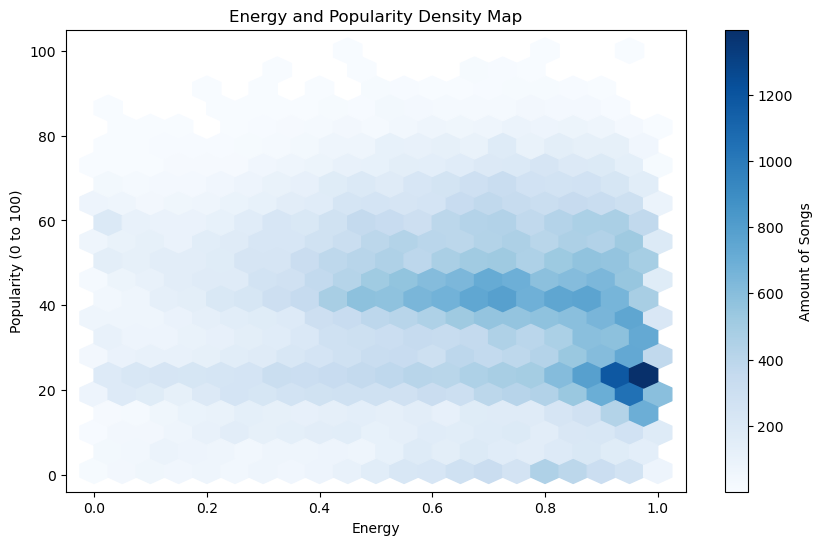

In [25]:
print(f"Visualisation of Energy vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["energy"], df["popularity"], gridsize=20, cmap='Blues', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Energy and Popularity Density Map")
plt.xlabel("Energy")
plt.ylabel("Popularity (0 to 100)")
plt.show()


####  Energy vs. Popularity — Insights
The hexbin density map reveals that **the majority of songs in this dataset are high-energy** (0.6–0.9 range), yet their popularity scores are spread widely across the full range (1–100). This tells us that energy alone is **not a strong predictor of popularity** — a highly energetic song can be completely obscure or enormously popular. With zero-popularity tracks removed, the density now more clearly concentrates in the mid-to-high energy range paired with mid-range popularity (20–60), reflecting the true engagement landscape of actively streamed music.


Visualisation of Danceability vs Popularity: 


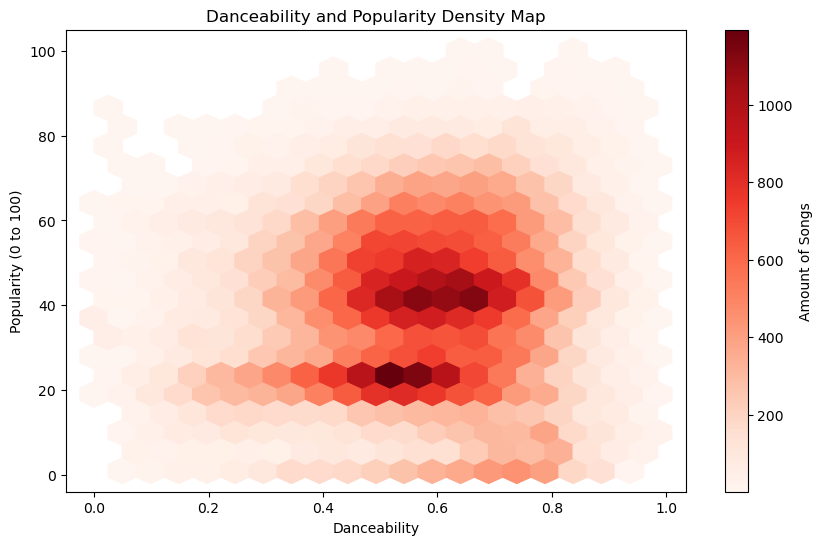

In [26]:
print(f"Visualisation of Danceability vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["danceability"], df["popularity"], gridsize=20, cmap='Reds', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Danceability and Popularity Density Map")
plt.xlabel("Danceability")
plt.ylabel("Popularity (0 to 100)")
plt.show()  

####  Danceability vs. Popularity — Insights
Songs with **danceability scores between 0.5 and 0.8** form the densest clusters, and this range also contains songs with higher popularity scores. Very low-danceability songs (< 0.3) rarely reach top popularity tiers, while the most popular songs tend to live in the moderate-to-high danceability zone. This suggests danceability may contribute positively to popularity, but the relationship is **non-linear and weak on its own** — other factors must be at play for a song to truly go viral.

Visualisation of Loudness vs Popularity: 


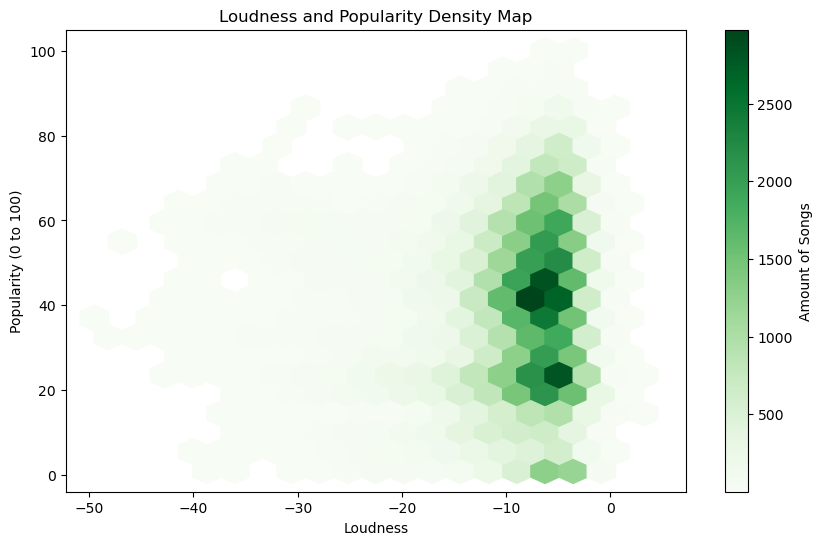

In [27]:
print(f"Visualisation of Loudness vs Popularity: ")

plt.figure(figsize=(10, 6))
plt.hexbin(df["loudness"], df["popularity"], gridsize=20, cmap='Greens', mincnt=1)
plt.colorbar(label='Amount of Songs')
plt.title("Loudness and Popularity Density Map")
plt.xlabel("Loudness")
plt.ylabel("Popularity (0 to 100)")
plt.show()  

####  Loudness vs. Popularity — Insights
Loudness in Spotify is measured in **dB (decibels)**, typically ranging from -60 dB (nearly silent) to 0 dB (maximum). The density map shows that most songs cluster around **-10 dB to -3 dB**, which is the standard loudness range for mastered commercial music. Notably, extremely quiet songs (below -20 dB) almost never appear in high-popularity territory, suggesting that a **minimum production loudness standard** is implicitly required to compete for listeners' attention. However, within the -10 to 0 dB window, loudness alone doesn't differentiate popular from unpopular songs.

Distribution of Popularity Scores: 


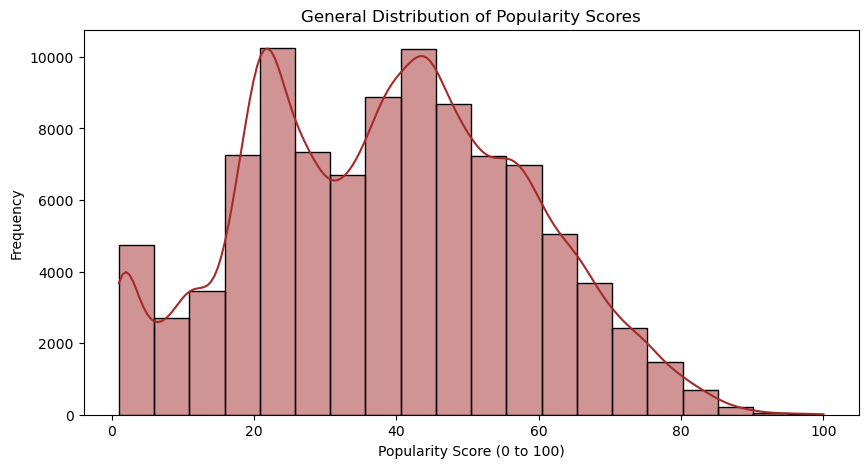

In [28]:
print("Distribution of Popularity Scores: ")
plt.figure(figsize=(10, 5))

sns.histplot(df["popularity"], bins=20, kde=True, color='brown')
plt.title("General Distribution of Popularity Scores")
plt.xlabel("Popularity Score (0 to 100)")
plt.ylabel("Frequency")
plt.show()

####  Popularity Distribution — Insights
After removing zero-popularity tracks, the distribution is **still right-skewed** but far more interpretable — the artificial spike at 0 (caused by unindexed or unlisted songs) is gone, revealing the true popularity landscape of actively streamed music. The bulk of songs now cluster in the **10–40 range**, with progressively fewer tracks reaching the top tiers (70–100). This remains a classic **long-tail distribution** typical in music streaming — most songs sit in moderate obscurity while a handful of hits dominate. For a prediction model, this imbalance still matters — the model must handle the skewness, otherwise it will be biased toward predicting mid-low popularity for everything. Techniques like log-transforming the target variable or using stratified sampling may still be necessary in the modeling phase.


Correlation Heatmap of Musical Features: 


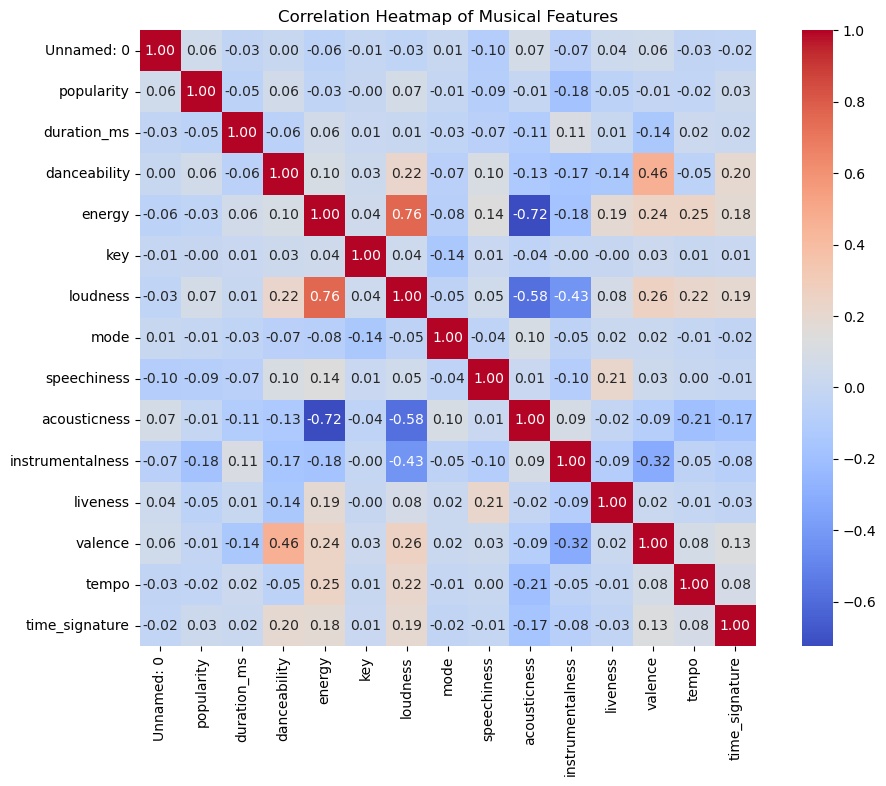

In [29]:
print("Correlation Heatmap of Musical Features: ")

numeric_columns = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 8))

sns.heatmap(numeric_columns.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Heatmap of Musical Features")
plt.show()

####  Correlation Heatmap — Insights
This heatmap is one of the most important outputs in the EDA. Key takeaways:
- **Energy & Loudness** are strongly positively correlated — louder songs tend to be more energetic, which makes intuitive sense given production styles.
- **Energy & Acousticness** are strongly negatively correlated — acoustic songs are typically low energy, and vice versa.
- **Popularity** shows **weak correlations** with most individual features, confirming that no single audio feature alone determines a song's success. This motivates using machine learning rather than simple rule-based systems.
- **Danceability and Valence** show a mild positive correlation, suggesting happier-sounding songs tend to be more danceable.

These relationships will guide **feature selection** in the modeling phase — highly collinear features (e.g., energy and loudness) may cause issues in linear models and could benefit from dimensionality reduction.

Outlier Detection for Song Duration: 


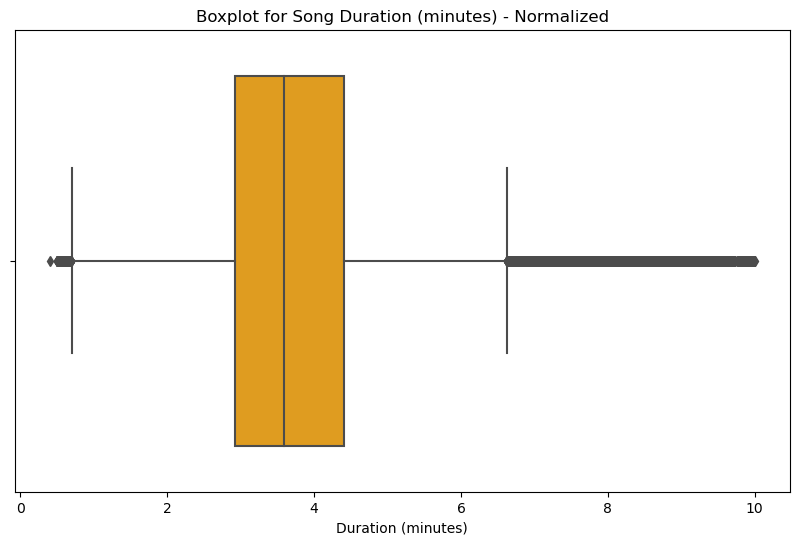

In [30]:
print(f"Outlier Detection for Song Duration: ")
df["duration_min"] = df["duration_ms"] / 60000
normal_songs = df[df["duration_min"] < 10]
plt.figure(figsize=(10, 6))
sns.boxplot(x=normal_songs["duration_min"], color='orange')
plt.title("Boxplot for Song Duration (minutes) - Normalized")
plt.xlabel("Duration (minutes)")
plt.show()

####  Song Duration — Insights
The boxplot (filtered to songs under 10 minutes) shows that **most songs fall between 2.5 and 4.5 minutes**, which aligns with the industry standard for radio-friendly tracks. The median is around 3–3.5 minutes. Songs significantly longer than 5 minutes are outliers — these are likely extended versions, live recordings, or songs from specific genres like jazz or classical. For modeling, very long songs may need to be treated carefully, as duration interacts with genre and could confound predictions. The original millisecond column was converted to minutes to make this distribution immediately interpretable.

Popularity by Track Mode (Major vs Minor): 


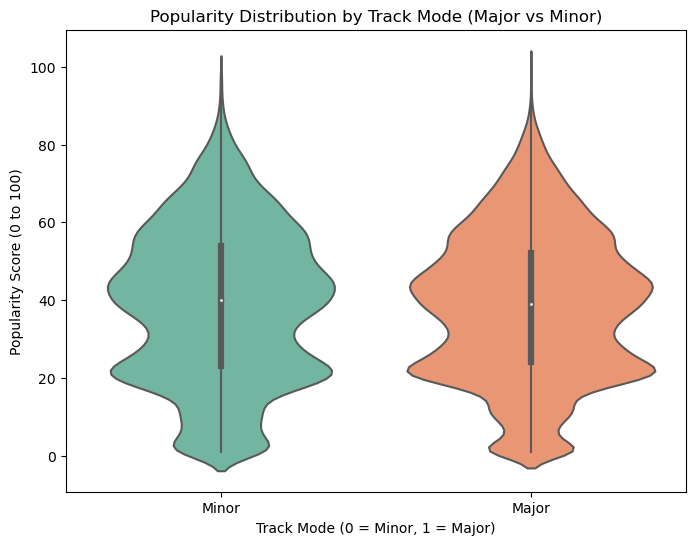

In [31]:
print(f"Popularity by Track Mode (Major vs Minor): ")
plt.figure(figsize=(8, 6))

sns.violinplot(x=df["mode"], y=df["popularity"], palette="Set2")
plt.title("Popularity Distribution by Track Mode (Major vs Minor)")
plt.xlabel("Track Mode (0 = Minor, 1 = Major)")
plt.ylabel("Popularity Score (0 to 100)") 
plt.xticks([0, 1], ['Minor', 'Major'])
plt.show()

####  Major vs. Minor Key & Popularity — Insights
The violin plot compares the popularity distributions of songs in **major (1) vs. minor (0) keys**. Both distributions appear broadly similar in shape, suggesting that the musical mode alone has **limited impact on popularity**. However, major key songs may show a slightly higher concentration in the mid-to-high popularity range, which aligns with psychological research showing that major keys tend to be perceived as happier and more accessible to general audiences. The wide spread in both distributions confirms that key alone is insufficient to predict a song's success — it is merely one of many contributing factors.

In [32]:
# Duration in ms --> Hard to interpret, so we convert it to minutes for better understanding.

df["duration_min"] = df["duration_ms"] / 60000

columns_to_drop = ["duration_ms"]

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
    
    
df = df.drop(columns=columns_to_drop)

display(df.head(20))
    


,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic,3.844433
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic,2.493500
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic,3.513767
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic,3.365550
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic,3.314217
5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic,3.570667
6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic,3.823333
7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic,4.049100
8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic,3.160217
9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic,3.426567


Multivariate Analysis of Energy, Valence and Popularity: 


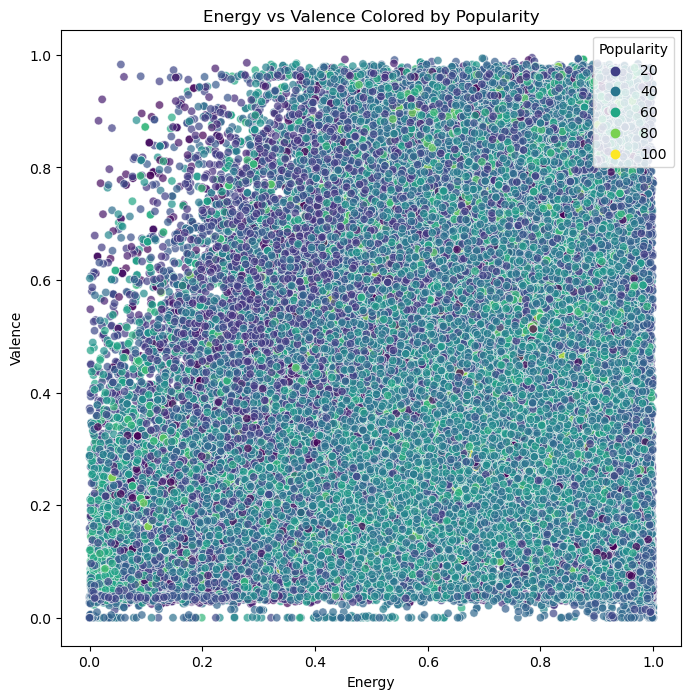

In [33]:
print(f"Multivariate Analysis of Energy, Valence and Popularity: ")
plt.figure(figsize=(8, 8))
sns.scatterplot(x=df["energy"], y=df["valence"], hue=df["popularity"], palette="viridis", alpha=0.7)
plt.title("Energy vs Valence Colored by Popularity")
plt.xlabel("Energy")
plt.ylabel("Valence")
plt.legend(title="Popularity", loc='upper right')
plt.show()

####  Energy vs. Valence (Colored by Popularity) — Insights
This scatter plot introduces a **three-way perspective**: the X-axis shows energy, the Y-axis shows valence (musical positiveness from 0 = sad/dark to 1 = happy/euphoric), and the color encodes popularity. A few patterns emerge:
- **High energy + high valence** songs (top-right quadrant) tend to be dance/pop hits, and many of the brighter/more popular points cluster here.
- **High energy + low valence** (top-left) captures intense, dark-sounding tracks — like aggressive EDM or metal — which can be popular within their niche but less universally so.
- **Low energy + low valence** (bottom-left) represents slow, melancholic tracks — these rarely chart in mainstream popularity.

This suggests that for **mass-market popularity**, a combination of energy and emotional positivity tends to help.

Heatmap of Average Popularity by Energy and Valence: 


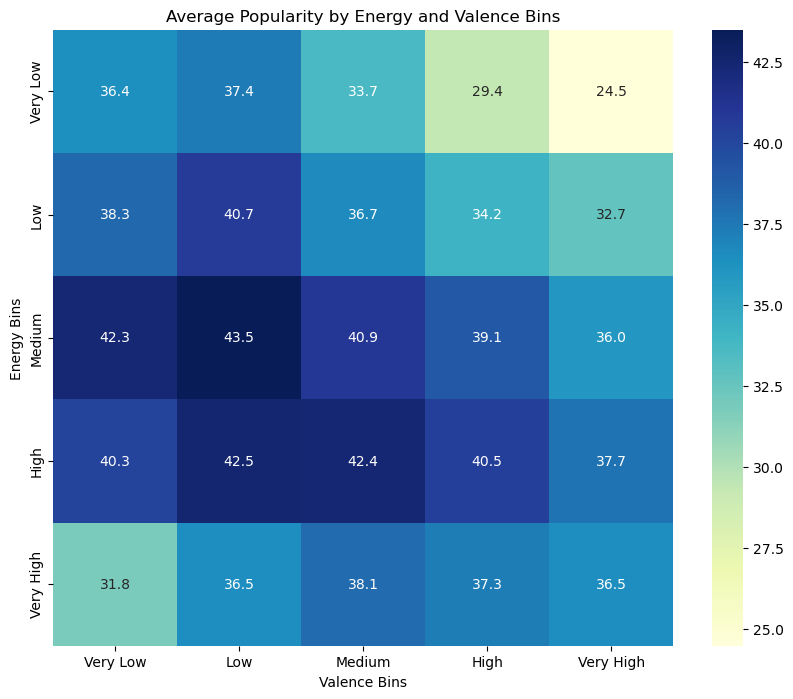

In [34]:
print(f"Heatmap of Average Popularity by Energy and Valence: ")

categories = ["Very Low", "Low", "Medium", "High", "Very High"]
df["energy_bin"] = pd.cut(df["energy"], bins=5, labels=categories)
df["valence_bin"] = pd.cut(df["valence"], bins=5, labels=categories)
heatmap_data = df.groupby(["energy_bin", "valence_bin"])["popularity"].mean().unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Popularity by Energy and Valence Bins")
plt.xlabel("Valence Bins")
plt.ylabel("Energy Bins")
plt.show()


####  Average Popularity by Energy & Valence Bins — Insights
This heatmap is one of the most actionable visualizations in this analysis. By binning both energy and valence into five levels and computing **average popularity per cell**, it reveals:
- The **highest average popularity** tends to appear in **medium-to-high energy + medium-to-high valence** combinations — this is the sweet spot for mainstream appeal.
- Very high energy with very low valence shows lower average popularity, consistent with niche genres being less universally popular.
- Interestingly, cells with very high valence but very low energy (calm and happy, e.g., acoustic pop) also show decent popularity — suggesting that **emotional tone matters more than raw intensity** in some cases.

This bin-level view strips away noise and gives a clearer "recipe" for what audio profiles tend to perform better on Spotify.

In [35]:
print("Descriptive Statistics of Key Musical Features: ")
features = ["energy", "danceability", "loudness", "valence", "tempo", "duration_min"]
print(df[features].describe())  

Descriptive Statistics of Key Musical Features: 
             energy  danceability      loudness       valence         tempo  \
count  97980.000000  97980.000000  97980.000000  97980.000000  97980.000000   
mean       0.645716      0.565668     -8.265888      0.468711    122.682976   
std        0.250406      0.172703      4.987856      0.258619     29.963442   
min        0.000000      0.000000    -49.531000      0.000000      0.000000   
25%        0.475000      0.456000    -10.057000      0.254000     99.966000   
50%        0.687000      0.578000     -7.071000      0.455000    122.743500   
75%        0.858000      0.693000     -5.027000      0.675000    141.091000   
max        1.000000      0.985000      4.532000      0.995000    243.372000   

       duration_min  
count  97980.000000  
mean       3.839890  
std        1.844892  
min        0.404433  
25%        2.924133  
50%        3.589700  
75%        4.422883  
max       87.288250  


####  Descriptive Statistics — Insights
The summary statistics reveal the **scale and spread of key features**:
- **Energy & Danceability** both range from 0 to 1 with means around 0.6–0.7, confirming that the dataset skews toward energetic and moderately danceable music.
- **Loudness** has a mean around -8 to -10 dB with a reasonably tight standard deviation, typical of mastered commercial tracks.
- **Valence** shows a wide spread (std close to 0.25), meaning the dataset contains everything from deeply melancholic to highly euphoric songs.
- **Tempo** typically averages around 120 BPM — the heartbeat of modern pop and dance music.
- **Duration** has a meaningful standard deviation, indicating variety in track length even after filtering extremes.

These statistics set the **baseline understanding** for every feature and are essential for choosing appropriate scaling methods (e.g., Min-Max vs. Standard Scaler) before model training.

Univariate Analysis of Tempo: 


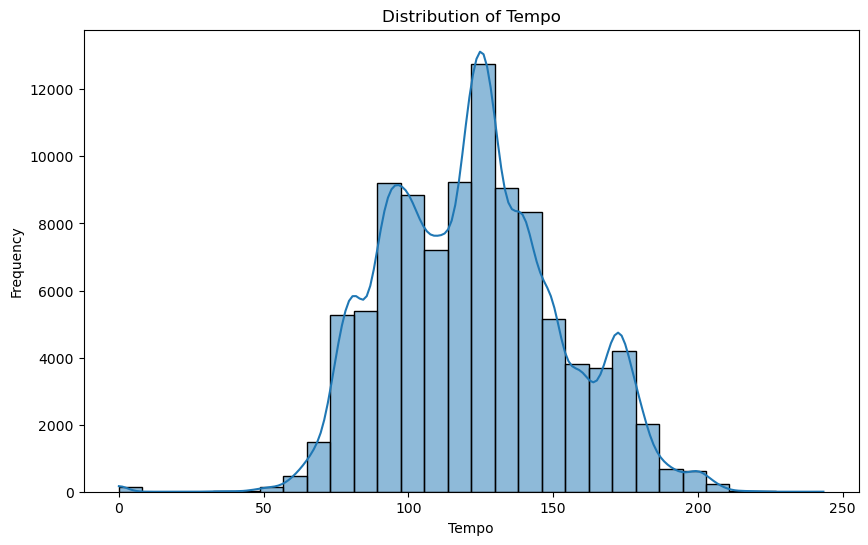

In [36]:
print(f"Univariate Analysis of Tempo: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["tempo"], bins=30, kde=True)
plt.title("Distribution of Tempo")
plt.xlabel("Tempo")
plt.ylabel("Frequency")
plt.show()


####  Tempo Distribution — Insights
The tempo distribution reveals interesting patterns about the musical pacing of songs in this dataset. A **bimodal shape** often appears, with peaks around **80–100 BPM** (chill/R&B/hip-hop territory) and **120–140 BPM** (pop/dance/EDM territory). This reflects the genre diversity within the dataset. The KDE curve smooths out the bins and makes the underlying shape clearer. For modeling, tempo is a useful feature because different tempo ranges correspond to different genres and listener demographics — both of which strongly influence popularity.

Univariate Analysis of Energy: 


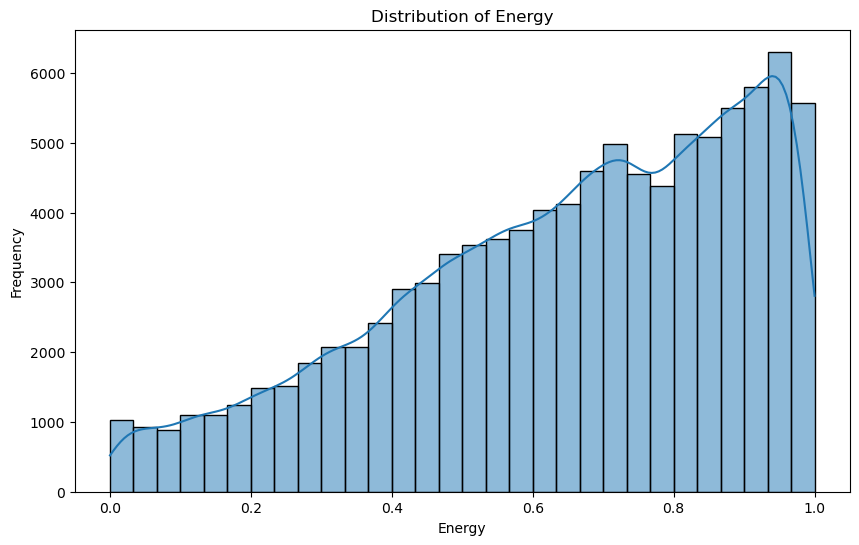

In [37]:
print(f"Univariate Analysis of Energy: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["energy"], bins=30, kde=True)
plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.show()

#### Energy Distribution — Insights
The energy distribution is **left-skewed**, meaning the dataset is dominated by high-energy tracks. The bulk of songs fall between 0.5 and 0.9, with the distribution tailing off at low energy values. This reflects the reality of music streaming platforms, which tend to favor and promote high-energy, engaging content. For modeling, this skew means energy has **low discriminative power** in the upper range — most songs are already energetic — but may be more informative at the lower end where energy variations are rarer and more distinctive.

Univariate Analysis of Danceability: 


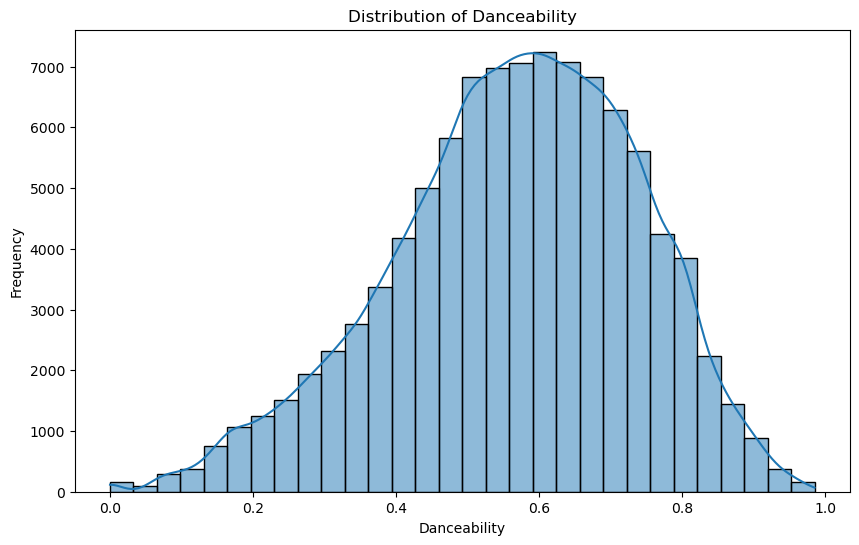

In [38]:
print(f"Univariate Analysis of Danceability: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["danceability"], bins=30, kde=True)
plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")
plt.show()

####  Danceability Distribution — Insights
Danceability follows a roughly **bell-shaped distribution** centered around 0.55–0.70, which is more symmetric than energy or popularity. This means the dataset is well-balanced between low and high danceability, making it a **more useful feature** for a prediction model — a symmetric distribution gives the model enough examples of both ends of the spectrum to learn meaningful patterns. The relatively low variance also suggests that extreme danceability values (very low or very high) are uncommon, making them potential signals worth paying attention to.

Univariate Analysis of Loudness: 


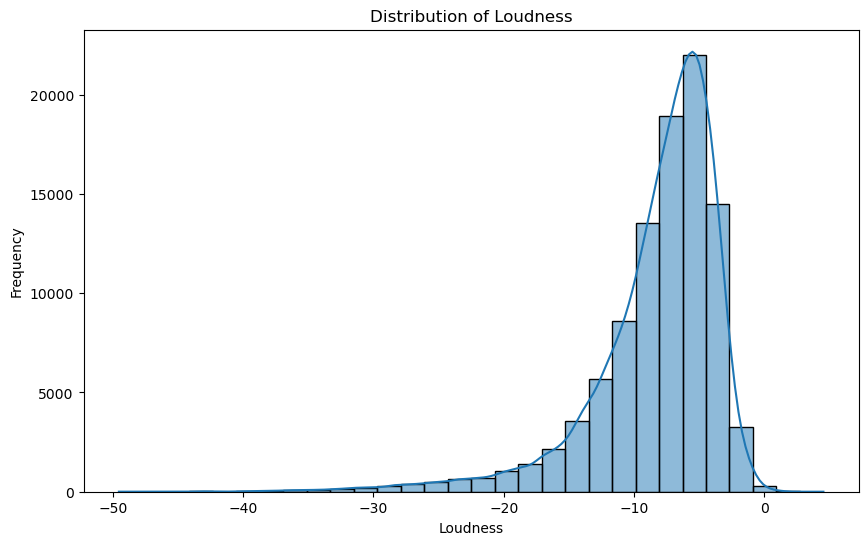

In [39]:
print("Univariate Analysis of Loudness: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["loudness"], bins=30, kde=True)
plt.title("Distribution of Loudness")
plt.xlabel("Loudness")
plt.ylabel("Frequency")
plt.show()

####  Loudness Distribution — Insights
The loudness distribution is concentrated tightly between **-12 dB and -4 dB**, which reflects the modern "loudness war" in music production — engineers master tracks to be as loud as possible to stand out. The distribution is **slightly left-skewed**, with a long tail stretching toward very quiet recordings. Songs quieter than -20 dB are likely live, classical, or archival recordings. This tight clustering means loudness has relatively low variance in the dataset, which may limit its standalone predictive power — but it still serves as a strong signal when combined with other features like acousticness and energy.

Univariate Analysis of Popularity: 


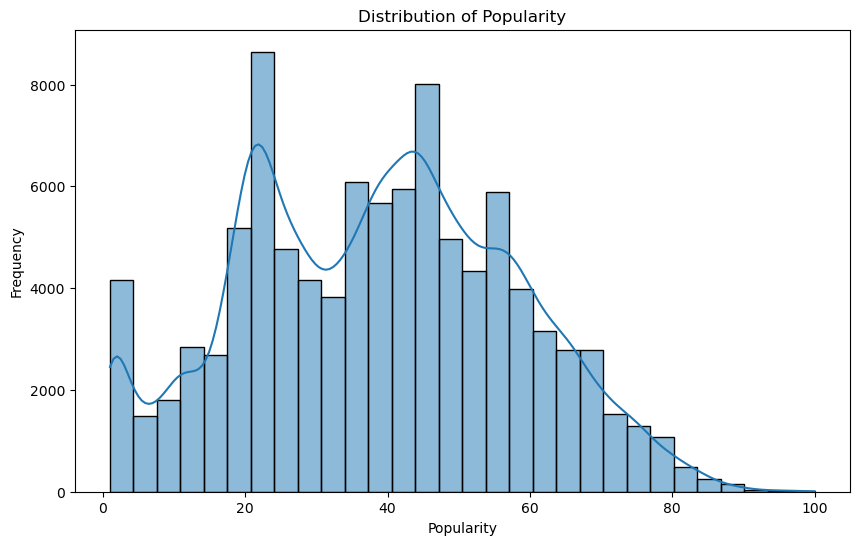

In [40]:
print("Univariate Analysis of Popularity: ")
plt.figure(figsize=(10, 6))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribution of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()

####  Popularity Distribution (Univariate) — Insights & EDA Wrap-Up
With zero-popularity songs filtered out, the univariate popularity histogram presents a **cleaner, right-skewed distribution** — the artificial pile-up at 0 is gone. The distribution now begins around 1–5 and peaks in the **20–40 range**, gradually tapering toward 100. This is the **target variable** for this project, and its distribution still has major implications:
- A regression model trained directly on raw popularity may still underperform for high-popularity predictions due to the natural imbalance between mid-range and viral tracks.
- Consider **log-transforming** popularity or **binning it** into categories (e.g., Low / Medium / High) to turn this into a classification problem.
- Stratified train/test splits remain essential to ensure all popularity tiers are represented during evaluation.

---
###  EDA Summary
After thorough exploration, the key findings are:
1. **No single feature predicts popularity well** — a multi-feature model is necessary.
2. **Energy, danceability, and valence together** paint the clearest picture of what makes a song widely appealing.
3. **Loudness, energy, and acousticness are strongly intercorrelated** — dimensionality reduction or careful feature selection is recommended.
4. **The target variable (popularity) remains right-skewed even after removing zero-popularity tracks** — preprocessing before modeling is still critical, but the data now reflects genuine listener engagement rather than catalogue noise.

These insights will directly inform the next steps: **feature engineering, model selection, and evaluation strategy**.
